# Regresión Logística - Clasificación de Sistemas Operativos

### Importacion de librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Carga de archivo

In [2]:
data_csv= pd.read_csv('Desktop/usuarios_win_mac_lin.csv', encoding= "ISO-8859-1")

In [3]:
data_csv.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


### Separacion de variables

In [4]:
X = data_csv[["duracion", "paginas", "acciones", "valor"]]

y = data_csv["clase"]

### Entrenamiento y prrueba

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Creacion y entrenamiento

In [6]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Realizar predicciones

In [7]:
y_pred = modelo.predict(X_test)

print(y_pred)

[2 2 2 2 2 2 0 2 2 0 0 2 0 0 2 2 2 0 2 0 0 0 0 1 0 2 0 0 0 0 0 1 1 1]


### Evaluacion

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7352941176470589


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       1.00      0.50      0.67         8
           2       0.64      1.00      0.78         9

    accuracy                           0.74        34
   macro avg       0.80      0.74      0.73        34
weighted avg       0.78      0.74      0.73        34



### Matriz de confusion

In [10]:
matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

Matriz de confusión:
[[12  0  5]
 [ 4  4  0]
 [ 0  0  9]]


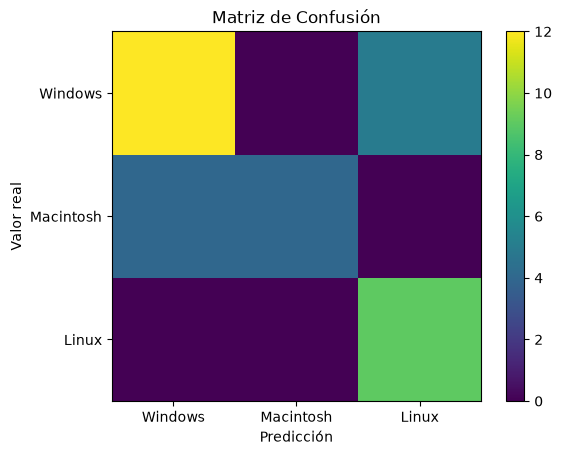

In [11]:
plt.imshow(matriz)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.colorbar()

plt.xticks([0, 1, 2], ["Windows", "Macintosh", "Linux"])
plt.yticks([0, 1, 2], ["Windows", "Macintosh", "Linux"])

plt.show()

## Predicción de un nuevo usuario

In [15]:
nuevo_usuario = pd.DataFrame({
    "duracion": [300],
    "paginas": [4],
    "acciones": [8],
    "valor": [16]
})

prediccion = modelo.predict(nuevo_usuario)

nombres_clases = {
    0: "Windows",
    1: "Macintosh",
    2: "Linux"
}

print("Datos del nuevo usuario:")
print("Duración:", nuevo_usuario["duracion"].iloc[0], "segundos")
print("Páginas vistas:", nuevo_usuario["paginas"].iloc[0])
print("Acciones:", nuevo_usuario["acciones"].iloc[0])
print("Valor de acciones:", nuevo_usuario["valor"].iloc[0])

print("\nSistema operativo predicho:",
      nombres_clases[prediccion[0]])

Datos del nuevo usuario:
Duración: 300 segundos
Páginas vistas: 4
Acciones: 8
Valor de acciones: 16

Sistema operativo predicho: Linux
